# JC Penney Hidden Gems Analysis  
### Combining Product Metadata, Customer Reviews & Sentiment Analysis  

### Summary

This notebook identifies “Hidden Gem” products at JC Penney. The items that customers love but do not receive enough visibility.  
Using data from product tables, user reviews, and JSON metadata, we merged structured and unstructured information to measure:

- **Customer satisfaction** (rating)
- **Customer emotion** (sentiment score)
- **Customer engagement** (number of reviews)
- **Product visibility indicators** (category, brand, images)

The goal is simple: highlight products that deserve promotion.


### 1. Setup  
We import essential analysis libraries.


In [98]:
import os
import re
import json
import math
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

print("✅ Setup ready.")


✅ Setup ready.


### 2. Loading the Data  
We load the CSV and JSON files and prepare them for analysis.  


In [99]:


# file paths
base = Path("JCPenneyFiles")
products = pd.read_csv(base / "products.csv", encoding="utf-8", on_bad_lines="skip", dtype=str)
reviews  = pd.read_csv(base / "reviews.csv",  encoding="utf-8", on_bad_lines="skip", dtype=str)
users    = pd.read_csv(base / "users.csv",    encoding="utf-8", on_bad_lines="skip", dtype=str)

# clean column names
def clean(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    return df

products = clean(products)
reviews  = clean(reviews)
users    = clean(users)

# convert numeric columns
num_cols = ["price", "av_score", "score"]
for col in num_cols:
    for df in (products, reviews):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")


In [100]:
from IPython.display import display

#print("Products:")
#display(products.head())

#print("Reviews:")
#display(reviews.head())

#print("Users:")
#display(users.head())


In [101]:
import json

def load_json_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

# Load files
jcp_products_json = load_json_lines("JCPenneyFiles/jcpenney_products.json")
jcp_reviewers_json = load_json_lines("JCPenneyFiles/jcpenney_reviewers.json")


### 3. Data Cleaning  
We prepare the data so it can be safely analyzed.  
Key steps:

- Remove duplicates
- Standardize columns
- Convert price fields to numeric
- Use `sku` as the single product identifier
- Extract useful metadata from JSON
- Keep users, reviews, and products separate (normalization)


In [102]:
import warnings
warnings.filterwarnings("ignore")


In [103]:
# create a unique product ID so we can isolate the single best-rated version (max avg score)

unique_products = (
    products
    .drop_duplicates(subset=["sku", "name", "description", "price"])
    .reset_index(drop=True)
)


In [104]:
#Now link every old uniq_id to the matching real product so we can use it as unique key:
mapping = products[["uniq_id", "sku"]].drop_duplicates()


In [105]:
#Removed unique key and av score because we want SKU as unique key
products_clean = unique_products.drop(columns=["uniq_id", "av_score"], errors="ignore")


In [106]:
# reviews was linked with product through uniq_id, we changed it to SKU as well
reviews_clean = reviews.merge(mapping, on="uniq_id", how="left")
reviews_clean = reviews_clean.drop(columns=["uniq_id"])


In [107]:
#Saved the clean files
products_clean.to_csv("products_clean.csv", index=False)
reviews_clean.to_csv("reviews_clean.csv", index=False)
mapping.to_csv("uniqid_sku_mapping.csv", index=False)


In [108]:
# To verify if it worked
#print("Products:")
#display(products_clean.head())

#print("Reviews:")
#display(reviews_clean.head())



### 4. Merging Metadata  
The JSON file contains additional product information (brand, category, image URL).  
We merge these fields to enrich the cleaned product table.


In [109]:
import pandas as pd

# load products into a flat dataframe
products_df = pd.DataFrame(jcp_products_json)

# drop nested relationship columns to keep products table normalized
if "Reviews" in products_df.columns:
    products_df = products_df.drop(columns=["Reviews"], errors="ignore")
if "Bought With" in products_df.columns:
    products_df = products_df.drop(columns=["Bought With"], errors="ignore")

print("Products DF:", products_df.shape)

reviews_rows = []

# flatten all review objects into one tidy reviews dataframe
for item in jcp_products_json:
    product_id = item.get("uniq_id")
    sku = item.get("sku")
    review_list = item.get("Reviews", [])

    for r in review_list:
        reviews_rows.append({
            "uniq_id": product_id,   # link review back to product
            "sku": sku,
            "username": r.get("User"),
            "review_text": r.get("Review"),
            "score": r.get("Score")
        })

reviews_from_json_df = pd.DataFrame(reviews_rows)
print("\nReviews From JSON (flattened):", reviews_from_json_df.shape)

# load reviewer metadata and normalize column names
reviewers_df = pd.DataFrame(jcp_reviewers_json)

reviewers_df = reviewers_df.rename(columns={
    "Username": "username",
    "DOB": "dob",
    "State": "state",
    "Reviewed": "reviewed_products"
})

print("\nReviewers DF:", reviewers_df.shape)


Products DF: (7982, 13)

Reviews From JSON (flattened): (39063, 5)

Reviewers DF: (5000, 4)


In [110]:
# Save products from JSON
products_df.to_csv("products_from_json.csv", index=False)

# Save flattened reviews from JSON
reviews_from_json_df.to_csv("reviews_from_json.csv", index=False)

# Save reviewer info
reviewers_df.to_csv("reviewers_from_json.csv", index=False)

print("✅ All JSON-derived DataFrames saved as CSV files!")


✅ All JSON-derived DataFrames saved as CSV files!


In [111]:
products_clean = pd.read_csv("products_clean.csv")   
reviews_clean = pd.read_csv("reviews_clean.csv")     
users_clean = pd.read_csv("JCPenneyFiles/users.csv")               

products_json = pd.read_csv("products_from_json.csv")

# keep only fields pulled from JSON that enrich product metadata
json_product_cols = [
    "sku",
    "brand",
    "category",
    "category_tree",
    "list_price",
    "sale_price",
    "product_image_urls",
    "average_product_rating",
    "total_number_reviews"
]

# dedupe JSON products so each SKU has one row of extra info
products_json_small = products_json[json_product_cols].drop_duplicates("sku")

# merge cleaned products with JSON-enriched attributes
enhanced_products = products_clean.merge(
    products_json_small,
    on="sku",
    how="left"     
)

print("Enhanced Products:", enhanced_products.shape)
#display(enhanced_products.head())


Enhanced Products: (6886, 12)


In [112]:
enhanced_products.to_csv("enhanced_products.csv", index=False)


### 5. Sentiment Analysis  
We score each review using VADER sentiment analysis, giving a value from -1 (negative) to +1 (positive).  
This helps measure customer emotion beyond star ratings.


In [113]:
# Apply sentiment analysis
reviews_clean["clean_review"] = reviews_clean["review"].apply(clean_text)
reviews_clean["sentiment"] = reviews_clean["clean_review"].apply(lambda x: sia.polarity_scores(x)["compound"])

display(reviews_clean.head(1))


,username,score,review,sku,clean_review,sentiment
0,fsdv4141,2,You never have to worry about the fit...Alfred Dunner clothing sizes are true to size and fits perfectly. Great value for the money.,pp5006380337,You never have to worry about the fit...Alfred Dunner clothing sizes are true to size and fits perfectly. Great value for the money.,0.942


In [114]:
reviews_clean.to_csv("reviews_clean.csv", index = False)

### 6. Product-Level Metrics  
We combine ratings, sentiment, and review volume to understand product performance.  
This creates a single table with:

- Average rating  
- Average sentiment  
- Number of reviews  
- Brand, category, price, image URL  


In [115]:
# combine review data with enriched product info (linked by SKU)
product_reviews = reviews_clean.merge(
    enhanced_products,
    on="sku",
    how="left"   # keep all reviews; attach product attributes when available
)

print("Merged Table:", product_reviews.shape)
#display(product_reviews.head())

# compute per-product aggregates: review stats + product metadata
product_metrics = (
    product_reviews
    .groupby("sku")
    .agg(
        avg_rating=("score", "mean"),            # average user rating
        avg_sentiment=("sentiment", "mean"),     # average sentiment score
        num_reviews=("score", "count"),          # review count
        name=("name", "first"),                  # basic product details
        description=("description", "first"),
        price=("price", "first"),
        brand=("brand", "first"),
        category=("category", "first"),
        category_tree=("category_tree", "first"),
        list_price=("list_price", "first"),
        sale_price=("sale_price", "first"),
        product_image_urls=("product_image_urls", "first")
    )
    .reset_index()
)

print("Product Metrics:", product_metrics.shape)
#display(product_metrics.head(2))


Merged Table: (63007, 17)
Product Metrics: (6043, 13)


### 7. Hidden Gem Score  
This original metric highlights products that customers love but have low visibility.

Hidden Gem Score = (Rating x Sentiment)/ log(Number of Reviews)

High score = high potential product.


In [116]:
import numpy as np

# Guard against missing values
product_metrics["avg_rating"] = product_metrics["avg_rating"].fillna(0)
product_metrics["avg_sentiment"] = product_metrics["avg_sentiment"].fillna(0)
product_metrics["num_reviews"] = product_metrics["num_reviews"].fillna(0)

# Compute the score
product_metrics["hidden_gem_score"] = (
    (product_metrics["avg_rating"] * product_metrics["avg_sentiment"]) /
    np.log(product_metrics["num_reviews"] + 2)
)

# Replace infinities with 0
product_metrics["hidden_gem_score"].replace([np.inf, -np.inf], 0, inplace=True)

# Sort from highest to lowest
hidden_gems = product_metrics.sort_values(
    by="hidden_gem_score",
    ascending=False
)

print("Top Hidden Gems:")
display(hidden_gems.head(2))


Top Hidden Gems:


,sku,avg_rating,avg_sentiment,num_reviews,name,description,price,brand,category,category_tree,list_price,sale_price,product_image_urls,hidden_gem_score
3541,pp5006082043,5.000,0.988,1,ZCO Shape Bootcut Jeans - Plus,Embellished back pockets give our bootcut jeans an eye-catching finish. elastic band provides comfort at the waist front mesh panels flatten the tummy area 5-pocket styling cotton/polyester/spande...,72.520,ZCO JEANS,sale,jcpenney|women|specialty-sizing|plus-size|sale,72.520,25.37,"http://s7d9.scene7.com/is/image/JCPenney/DP0824201517011894M.tif?hei=380&amp;wid=380&op_usm=.4,.8,0,0&resmode=sharp2&op_usm=1.5,.8,0,0&resmode=sharp",4.495
5513,pp5006750422,5.000,0.985,1,Carters® 3-pc. Seahorse Pajama Set - Toddler Girls 2t-5t,"With choices of bottoms, this pajama set will make her feel extra comfy every night. includes flutter-sleeve shirt, pants and shorts screen-print graphics no-pinch elastic waistbands polyester was...",31.420,Carter's,pajamas,jcpenney|kids|pajamas,31.420,15.7,"http://s7d9.scene7.com/is/image/JCPenney/DP0216201617021841M.tif?hei=380&amp;wid=380&op_usm=.4,.8,0,0&resmode=sharp2&op_usm=1.5,.8,0,0&resmode=sharp",4.484


In [117]:
# flag products whose hidden_gem_score is high enough to qualify as strong hidden gems
threshold = 4.55 / 2   # 2.275

strong_hidden_gems = product_metrics[
    product_metrics["hidden_gem_score"] >= threshold
]


In [118]:
strong_hidden_gems.to_csv("strong_hidden_gems.csv", index = False)

In [119]:
percentage_strong = (len(strong_hidden_gems) / len(product_metrics)) * 100
percentage_strong


2.796624193281483

### 8. Visualizing Product Performance  

These charts highlight the hidden gems from whole data set. it shows that 2.8% of products are strong hidden gems.


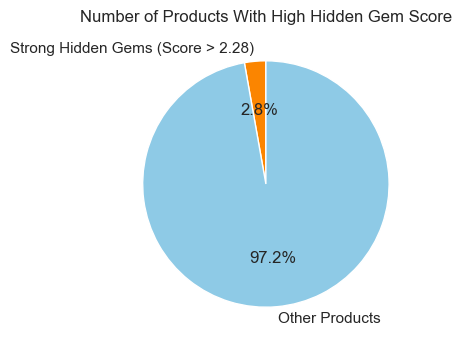

In [120]:
# pie chart comparing strong hidden gems vs. the rest of the catalog
labels = ["Strong Hidden Gems (Score > 2.28)", "Other Products"]
sizes = [len(strong_hidden_gems), len(product_metrics) - len(strong_hidden_gems)]
colors = ["#fb8500", "#8ecae6"]

plt.figure(figsize=(4,4))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)
plt.title("Number of Products With High Hidden Gem Score")
plt.show()


In [121]:
hg_metrics = pd.read_csv("strong_hidden_gems.csv")


Lets identify top three hidden gems

In [122]:
# select the top 3 products by hidden gem score
top3 = (
    hg_metrics
    .sort_values("hidden_gem_score", ascending=False)
    .head(3)[["name", "avg_rating"]]
)

print("Top 3 Hidden Gem Products :")
display(top3)


Top 3 Hidden Gem Products :


,name,avg_rating
79,ZCO Shape Bootcut Jeans - Plus,5.000
143,Carters® 3-pc. Seahorse Pajama Set - Toddler Girls 2t-5t,5.000
1,Mens 6mm Tungsten Carbide Ring,5.000


In [123]:
positive = hg_metrics[hg_metrics["avg_sentiment"] > 0]


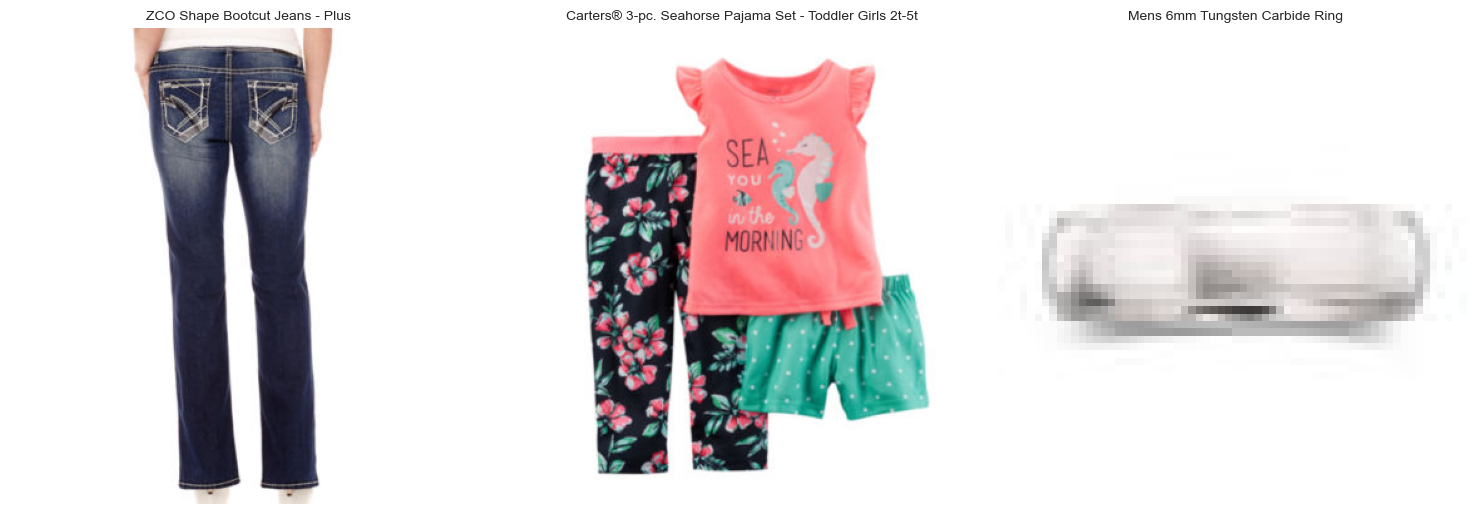

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

# Plot setup
plt.figure(figsize=(15, 6))

for i, (_, row) in enumerate(top3.iterrows()):
    img_urls = str(row["product_image_urls"]).split(",")  # handle multiple URLs
    img_url = img_urls[0].strip()                         # take the first image

    # Fetch the image
    response = requests.get(img_url)
    img = Image.open(BytesIO(response.content))

    # Plot
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(row["name"], fontsize=10)

plt.tight_layout()
plt.show()


We are going to identify top 3 brands as well

In [131]:
top3_brands = (
    positive.groupby("brand")["avg_sentiment"]
    .count()
    .sort_values(ascending=False)
    .head(3)
)


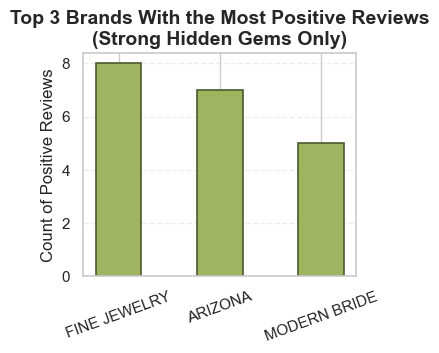

In [132]:
plt.figure(figsize=(4,4))   

plt.bar(
    top3_brands.index,
    top3_brands.values,
    width=0.45,              
    color="#9fb360",
    edgecolor="#4a5b2c",
    linewidth=1.2
)

plt.title("Top 3 Brands With the Most Positive Reviews\n(Strong Hidden Gems Only)",
          fontsize=14, weight="bold")

plt.ylabel("Count of Positive Reviews", fontsize=12)

plt.xticks(rotation=20, ha="center", fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout(pad=2)
plt.show()
